In [50]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Lenovostore\Downloads\Final-50-stocks.csv");
df.head()

,DATE,TATASTEEL,WIPRO,TITAN,ULTRACEMO,TECHM,RELIANCE,SHREECEM,SUNPHARMA,TATAMOTORS,...,BPCL,BRITANNIA,ADANIPORTS,BAJAJFINSERV,BAJAJFINANCE,BHARTIARTL,AXISBANK,BAJAJ-AUTO,ASIANPAINT,UPL
0,2010-01-11,591.90,423.70,3792.50,6737.95,735.60,1093.20,2116.10,2190.70,1170.60,...,754.80,413.15,NaN,467.25,798.60,335.30,1513.60,1530.75,2705.05,NaN
1,2010-01-12,613.55,414.70,3781.90,5443.70,671.15,988.80,2094.10,448.65,1286.75,...,697.95,410.30,NaN,481.65,713.30,350.55,1424.45,1571.20,2680.40,NaN
2,2010-02-11,599.05,433.85,3818.70,6735.25,724.55,1074.85,2164.55,2190.45,1154.25,...,772.75,413.60,NaN,472.10,806.40,329.25,1526.60,1548.75,2792.80,NaN
3,2010-02-12,622.75,426.05,3784.20,5368.40,676.35,1011.15,2022.35,452.90,1320.15,...,685.80,412.45,NaN,484.35,741.85,346.10,1455.35,1574.30,2651.85,NaN
4,2010-03-11,609.60,434.70,3833.05,6858.65,732.50,1065.30,2261.40,2249.30,1185.55,...,765.60,415.75,NaN,480.15,799.25,328.40,1536.10,1582.35,2694.90,NaN


In [51]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)
df.isnull().sum()

DATE               0
TATASTEEL          0
WIPRO              0
TITAN              0
ULTRACEMO          0
TECHM              0
RELIANCE           0
SHREECEM           0
SUNPHARMA          0
TATAMOTORS         0
TCS                0
SBIN               0
NESTLEIND          0
NTPC               0
M&M                0
MARUTI             0
ONGC               0
POWERGRID          0
JSWSTEEL           0
KOTAKBANK          0
LT                 0
ICICIBANK          0
INDUSBANK          0
INFY             174
IOC                0
ITC                0
HEROMOTOCO       202
HINDALCO           0
HINDUNILVR         0
HCLTECH            0
HDFCBANK           0
HDFC               0
DRREDDYS           0
EICHERMOTOR        0
GRASIM             0
CIPLA              0
COALINDIA         12
BPCL               0
BRITANNIA          0
ADANIPORTS      1460
BAJAJFINSERV       0
BAJAJFINANCE       0
BHARTIARTL         0
AXISBANK           0
BAJAJ-AUTO         0
ASIANPAINT         0
UPL              752
dtype: int64

In [52]:
for col in df.columns:
    if col != "DATE":
        df[col] = df[col].ffill()
        df[col] = df[col].bfill()


In [53]:
stock = "RELIANCE"
data = df[["DATE", stock]].copy()
data.head()

,DATE,RELIANCE
0,2010-01-11,1093.20
1,2010-01-12,988.80
2,2010-02-11,1074.85
3,2010-02-12,1011.15
4,2010-03-11,1065.30


In [54]:
# Create daily returns
data['Return'] = data['RELIANCE'].pct_change()

# Remove the first row (it becomes NaN because there is no previous day)
data = data.dropna().reset_index(drop=True)

data.head()

,DATE,RELIANCE,Return
0,2010-01-12,988.80,-0.095499
1,2010-02-11,1074.85,0.087025
2,2010-02-12,1011.15,-0.059264
3,2010-03-11,1065.30,0.053553
4,2010-03-12,1005.90,-0.055759


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns


In [56]:
last_1_year = data[data['DATE'] >= data['DATE'].max() - pd.DateOffset(years=1)].copy()

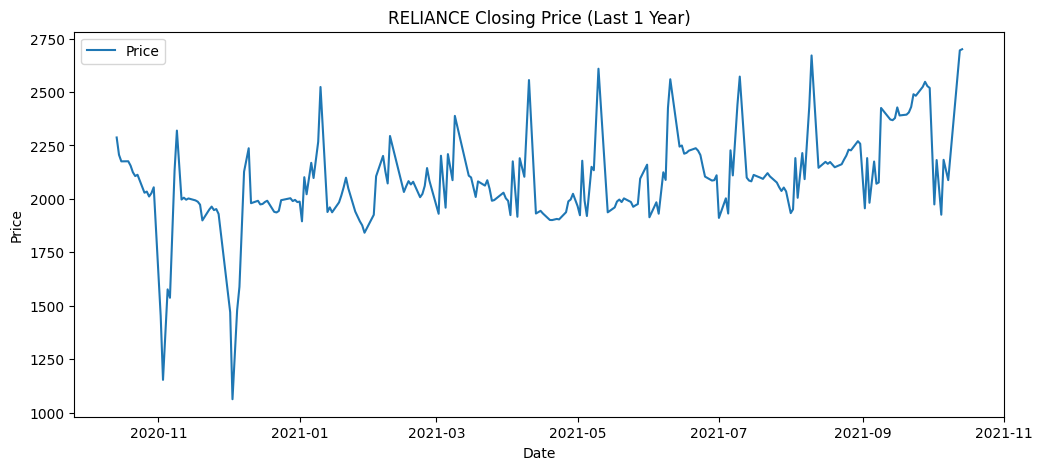

In [57]:
plt.figure(figsize=(12,5))
plt.plot(last_1_year['DATE'], last_1_year['RELIANCE'], label='Price')
plt.title('RELIANCE Closing Price (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

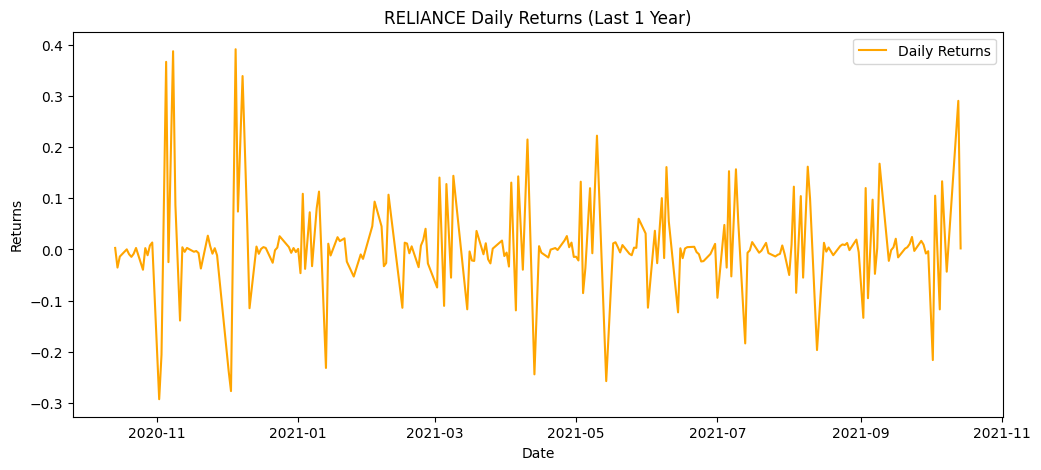

In [58]:
plt.figure(figsize=(12,5))
plt.plot(last_1_year['DATE'], last_1_year['Return'], color='orange', label='Daily Returns')
plt.title('RELIANCE Daily Returns (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()


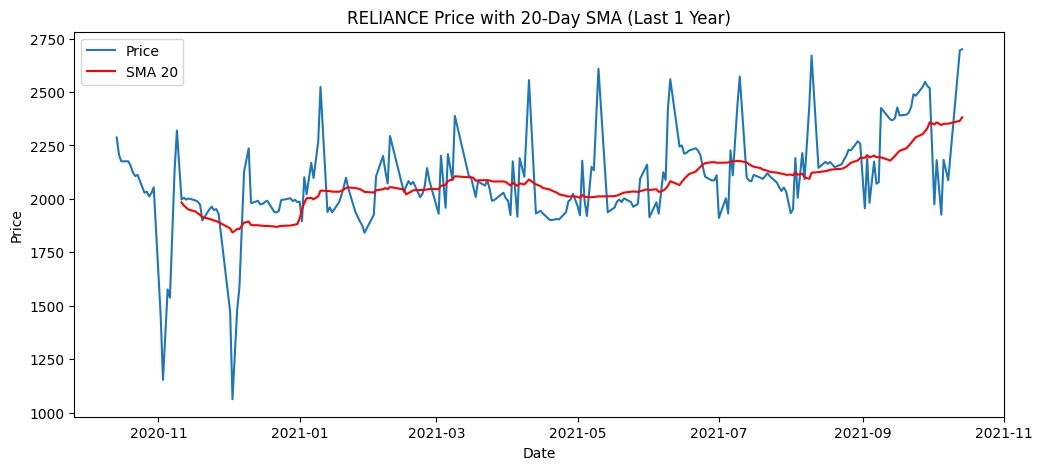

In [59]:
last_1_year['SMA_20'] = last_1_year['RELIANCE'].rolling(20).mean()

plt.figure(figsize=(12,5))
plt.plot(last_1_year['DATE'], last_1_year['RELIANCE'], label='Price')
plt.plot(last_1_year['DATE'], last_1_year['SMA_20'], label='SMA 20', color='red')
plt.title('RELIANCE Price with 20-Day SMA (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


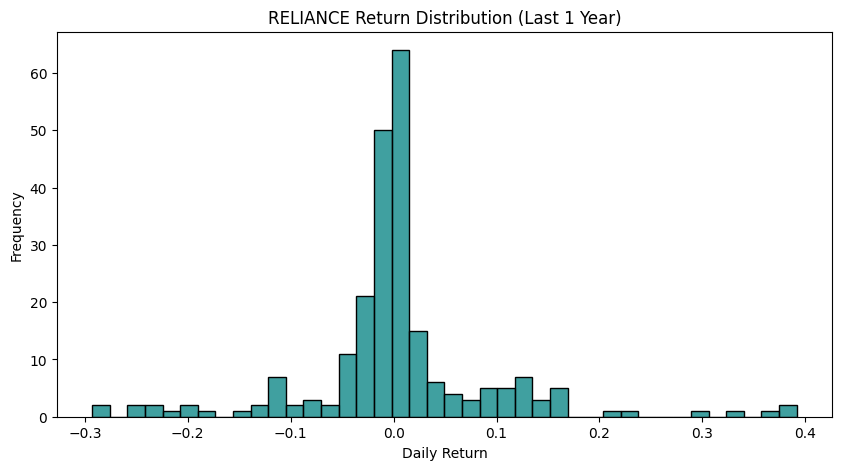

In [60]:
plt.figure(figsize=(10,5))
sns.histplot(last_1_year['Return'], bins=40, color='teal')
plt.title('RELIANCE Return Distribution (Last 1 Year)')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

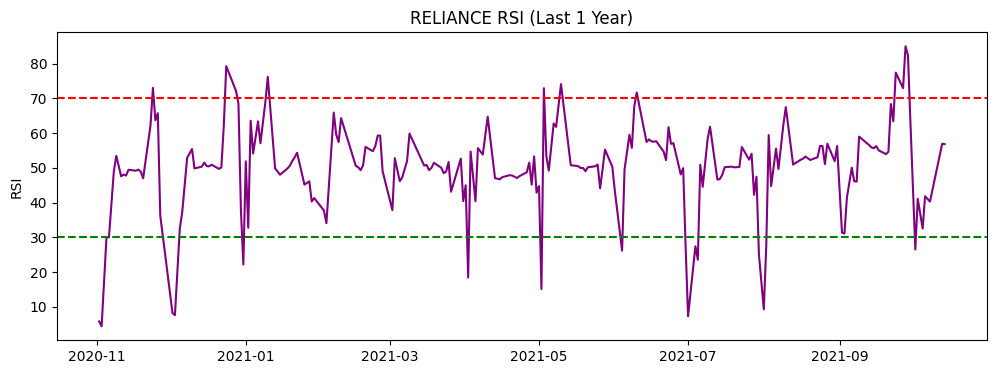

In [61]:
delta = last_1_year['RELIANCE'].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

RS = avg_gain / avg_loss
last_1_year['RSI'] = 100 - (100 / (1 + RS))

plt.figure(figsize=(12,4))
plt.plot(last_1_year['DATE'], last_1_year['RSI'], color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('RELIANCE RSI (Last 1 Year)')
plt.ylabel('RSI')
plt.show()


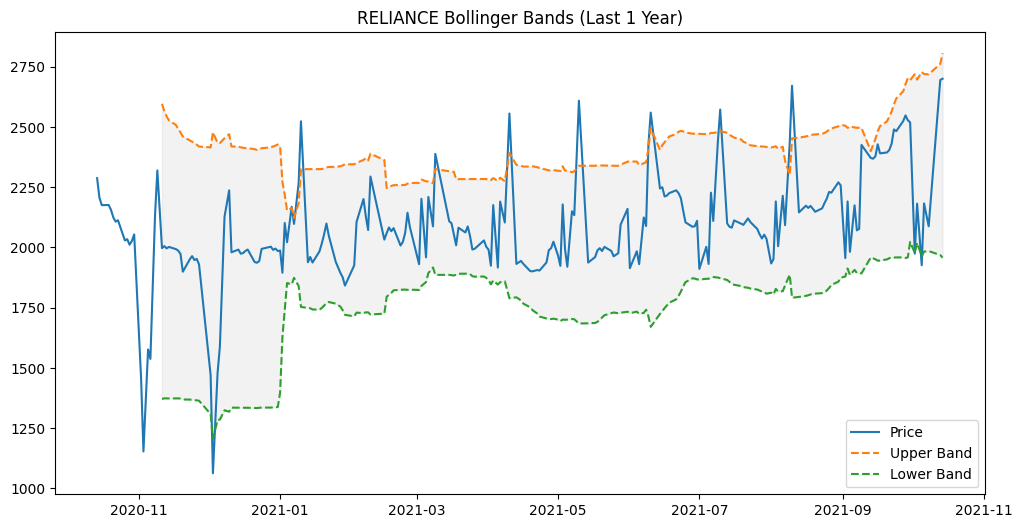

In [62]:
last_1_year['SMA_20'] = last_1_year['RELIANCE'].rolling(20).mean()
last_1_year['STD_20'] = last_1_year['RELIANCE'].rolling(20).std()

last_1_year['Upper_Band'] = last_1_year['SMA_20'] + 2 * last_1_year['STD_20']
last_1_year['Lower_Band'] = last_1_year['SMA_20'] - 2 * last_1_year['STD_20']

plt.figure(figsize=(12,6))
plt.plot(last_1_year['DATE'], last_1_year['RELIANCE'], label='Price')
plt.plot(last_1_year['DATE'], last_1_year['Upper_Band'], label='Upper Band', linestyle='--')
plt.plot(last_1_year['DATE'], last_1_year['Lower_Band'], label='Lower Band', linestyle='--')
plt.fill_between(last_1_year['DATE'], last_1_year['Lower_Band'], last_1_year['Upper_Band'], 
                 color='gray', alpha=0.1)
plt.title('RELIANCE Bollinger Bands (Last 1 Year)')
plt.legend()
plt.show()

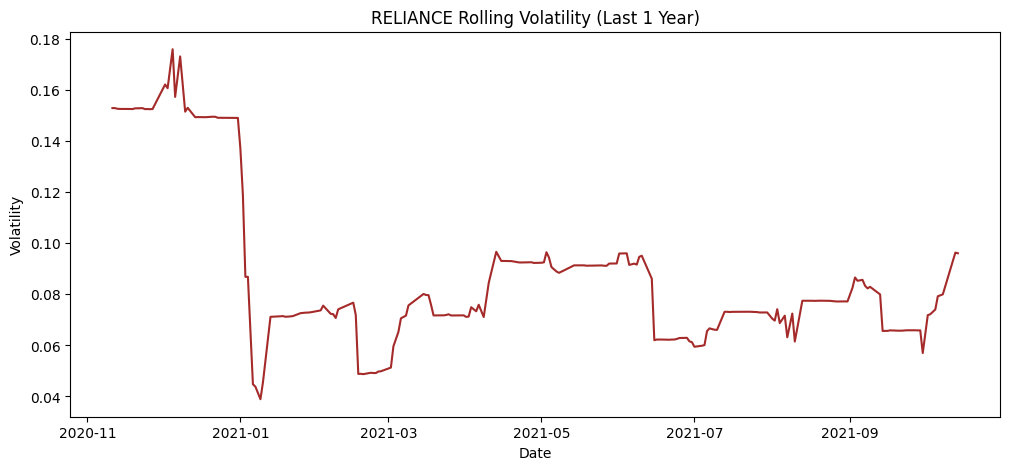

In [63]:
last_1_year['Volatility_20'] = last_1_year['Return'].rolling(20).std()

plt.figure(figsize=(12,5))
plt.plot(last_1_year['DATE'], last_1_year['Volatility_20'], color='brown')
plt.title('RELIANCE Rolling Volatility (Last 1 Year)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

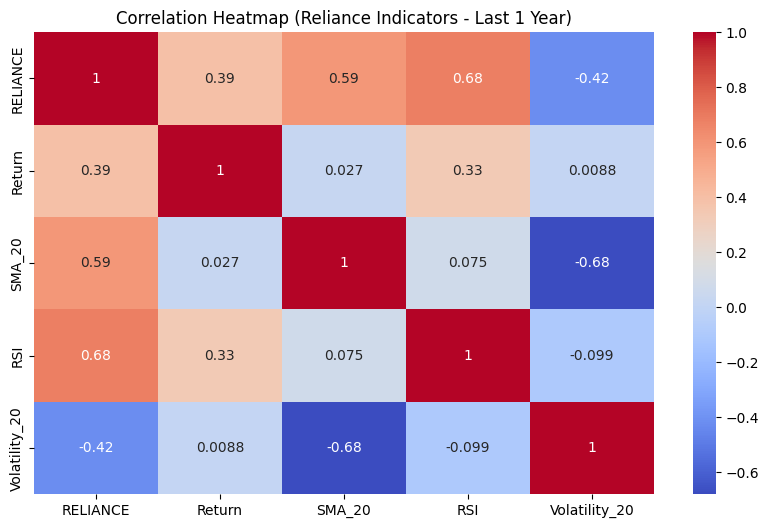

In [64]:
# Select numerical feature columns
feature_cols = ['RELIANCE', 'Return', 'SMA_20', 'RSI', 'Volatility_20']

plt.figure(figsize=(10,6))
sns.heatmap(last_1_year[feature_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Reliance Indicators - Last 1 Year)")
plt.show()

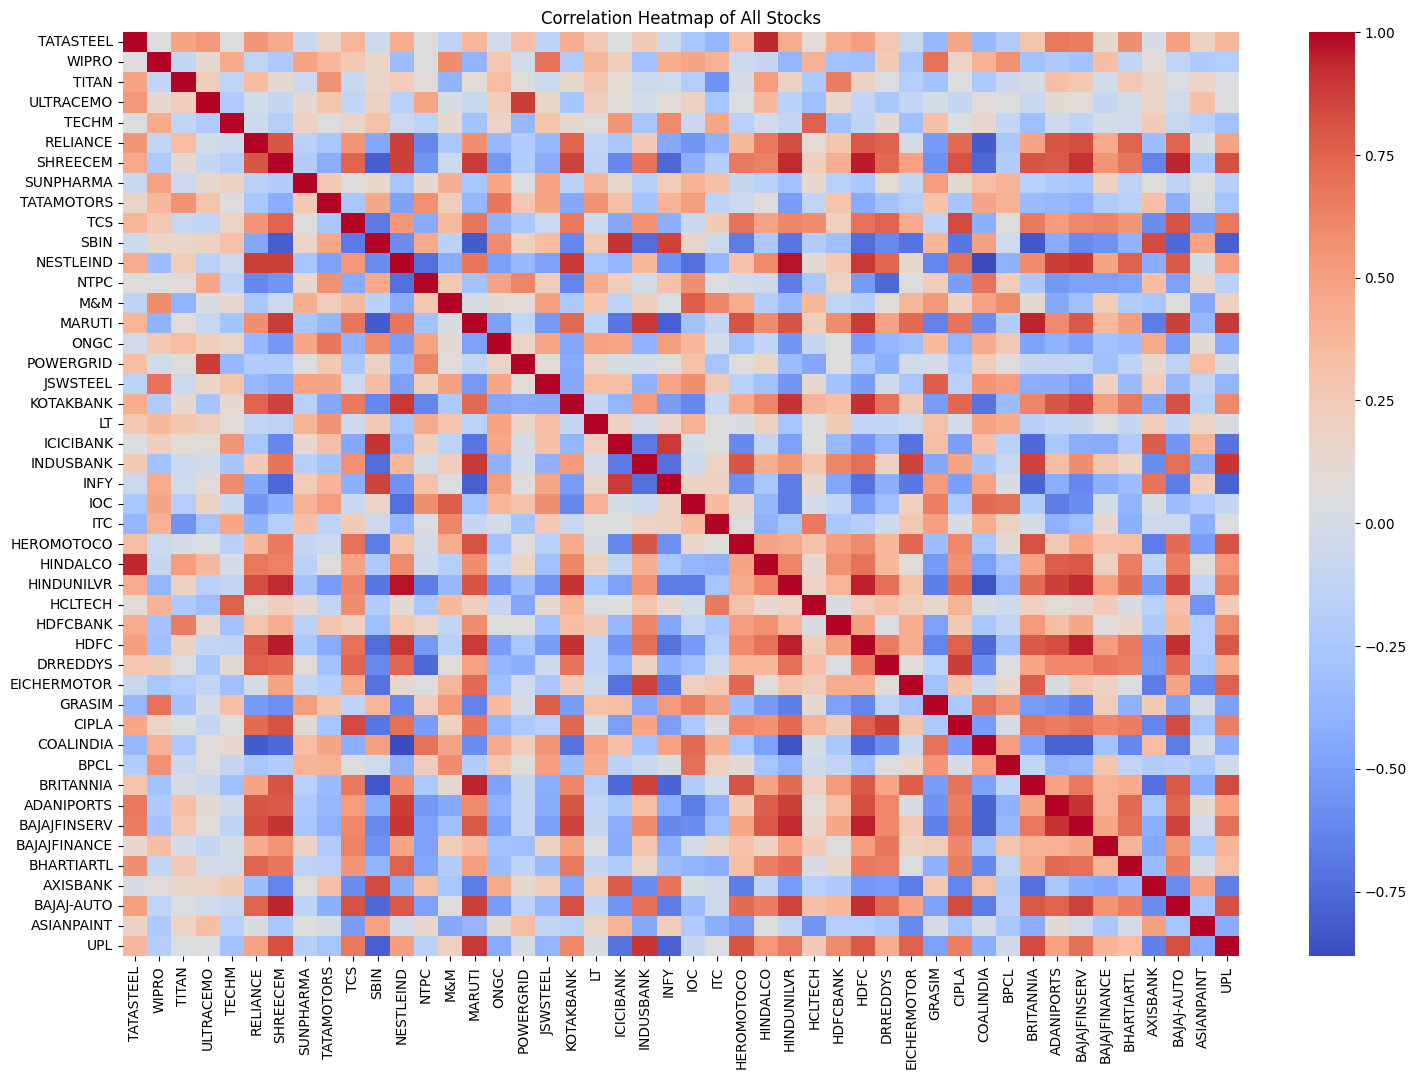

In [65]:
plt.figure(figsize=(18,12))
sns.heatmap(df.drop(columns=['DATE']).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap of All Stocks")
plt.show()

In [96]:
# ===============================================================
#  PART 2 (UPDATED) - TRAIN MULTIPLE MODELS PER STOCK (DEGREE 2 POLYNOMIAL)
#  Jupyter Lab ready. Uses CSV path:
#  C:\Users\Lenovostore\Downloads\Final-50-stocks.csv
#
#  WHAT IT DOES
#   - For each stock column (excluding DATE) it:
#       * creates features (same feature set we agreed)
#       * trains these models: LinearRegression, PolynomialRegression(deg2),
#         RandomForestRegressor, LogisticRegression, DecisionTreeClassifier, KMeans (per-stock)
#       * evaluates each model on a time-based test split
#       * SAVES all trained models to models_all/ for presentation
#       * COPIES only the app-required artifacts to models/:
#            - RandomForestRegressor  -> {STOCK}_reg.pkl
#            - LogisticRegression     -> {STOCK}_clf.pkl
#            - StandardScaler         -> {STOCK}_scaler.pkl
#            - Feature list           -> {STOCK}_features.pkl
#   - Writes a training_summary.csv for all stocks and all models' key metrics
#
#  NOTE:
#   - Polynomial regression uses sklearn PolynomialFeatures(degree=2) + LinearRegression
#   - KMeans uses k=3 by default (you can change)
# ===============================================================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path
import math
import joblib
import numpy as np
import pandas as pd
from datetime import datetime

# ML models & tools
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# -----------------------
# CONFIG
# -----------------------
CSV_PATH = r"C:\Users\Lenovostore\Downloads\Final-50-stocks.csv"
MIN_ROWS = 100                # skip stocks with fewer rows after FE
TEST_RATIO = 0.2              # last 20% for test (time-based split)
RANDOM_STATE = 42
KMEANS_K = 3                  # clusters per-stock
MODEL_DIR_ALL = Path("models_all")   # saves ALL trained models (presentation)
MODEL_DIR_APP = Path("models")       # saves only app-required artifacts
MODEL_DIR_ALL.mkdir(exist_ok=True)
MODEL_DIR_APP.mkdir(exist_ok=True)

# -----------------------
# FEATURE ENGINEERING
# -----------------------
def add_features_price_series(df_price: pd.DataFrame, stock_col: str) -> pd.DataFrame:
    data = df_price[["DATE", stock_col]].copy().rename(columns={stock_col: "Close"})
    data["Return"] = data["Close"].pct_change()
    data["lag1"] = data["Return"].shift(1)
    data["lag2"] = data["Return"].shift(2)
    data["lag3"] = data["Return"].shift(3)
    data["SMA_5"] = data["Close"].rolling(5).mean()
    data["SMA_10"] = data["Close"].rolling(10).mean()
    data["EMA_5"] = data["Close"].ewm(span=5, adjust=False).mean()
    data["EMA_10"] = data["Close"].ewm(span=10, adjust=False).mean()
    data["Volatility_5"] = data["Return"].rolling(5).std()
    data["Volatility_10"] = data["Return"].rolling(10).std()
    # RSI (14)
    delta = data["Close"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    data["RSI"] = 100 - (100 / (1 + rs))
    # Bollinger Bands (on price)
    data["SMA_20"] = data["Close"].rolling(20).mean()
    data["STD_20"] = data["Close"].rolling(20).std()
    data["Upper_Band"] = data["SMA_20"] + 2 * data["STD_20"]
    data["Lower_Band"] = data["SMA_20"] - 2 * data["STD_20"]
    # Targets: next day
    data["Target_Return_Next"] = data["Return"].shift(-1)
    data["Target_Dir_Next"] = (data["Target_Return_Next"] > 0).astype(int)
    data = data.dropna().reset_index(drop=True)
    return data

# feature list (order must be preserved)
FEATURE_COLUMNS = [
    'Return', 'lag1', 'lag2', 'lag3',
    'SMA_5', 'SMA_10', 'EMA_5', 'EMA_10',
    'Volatility_5', 'Volatility_10',
    'RSI', 'SMA_20', 'STD_20', 'Upper_Band', 'Lower_Band'
]

# -----------------------
# LOAD CSV
# -----------------------
df_all = pd.read_csv(CSV_PATH)
if "DATE" not in df_all.columns:
    first_col = df_all.columns[0]
    df_all = df_all.rename(columns={first_col: "DATE"})
df_all["DATE"] = pd.to_datetime(df_all["DATE"])
df_all = df_all.sort_values("DATE").reset_index(drop=True)

stock_cols = [c for c in df_all.columns if c.upper() != "DATE"]
print("Loaded CSV:", CSV_PATH)
print("Total stocks found:", len(stock_cols))
print("Example columns:", stock_cols[:6])

# -----------------------
# SUMMARY STORE
# -----------------------
rows = []

# -----------------------
# MAIN LOOP: TRAIN PER STOCK
# -----------------------
for stock in stock_cols:
    try:
        data = add_features_price_series(df_all[["DATE", stock]].rename(columns={stock: stock}), stock)
    except Exception as e:
        print(f"Skipping {stock}: feature error ->", e)
        continue

    if data.shape[0] < MIN_ROWS:
        print(f"Skipping {stock}: not enough rows ({data.shape[0]})")
        continue

    # prepare X/y and time split
    X = data[FEATURE_COLUMNS].copy()
    y_reg = data["Target_Return_Next"].copy()
    y_clf = data["Target_Dir_Next"].copy()

    n = len(X)
    split_at = int(math.floor(n * (1 - TEST_RATIO)))
    X_train, X_test = X.iloc[:split_at].copy(), X.iloc[split_at:].copy()
    y_reg_train, y_reg_test = y_reg.iloc[:split_at].copy(), y_reg.iloc[split_at:].copy()
    y_clf_train, y_clf_test = y_clf.iloc[:split_at].copy(), y_clf.iloc[split_at:].copy()

    # scaling (use for LR, Logistic, Poly, KMeans)
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # ----------------------------------------
    # 1) Linear Regression
    # ----------------------------------------
    lin = LinearRegression()
    lin.fit(X_train_s, y_reg_train)               # scale for stability
    y_lin_pred = lin.predict(X_test_s)
    lin_rmse = math.sqrt(mean_squared_error(y_reg_test, y_lin_pred))
    lin_mae = mean_absolute_error(y_reg_test, y_lin_pred)
    lin_r2 = r2_score(y_reg_test, y_lin_pred)

    # ----------------------------------------
    # 2) Polynomial Regression (degree 2)
    # ----------------------------------------
    poly_fe = PolynomialFeatures(degree=2, include_bias=False)
    X_train_poly = poly_fe.fit_transform(X_train_s)
    X_test_poly = poly_fe.transform(X_test_s)
    poly_lin = LinearRegression()
    poly_lin.fit(X_train_poly, y_reg_train)
    y_poly_pred = poly_lin.predict(X_test_poly)
    poly_rmse = math.sqrt(mean_squared_error(y_reg_test, y_poly_pred))
    poly_mae = mean_absolute_error(y_reg_test, y_poly_pred)
    poly_r2 = r2_score(y_reg_test, y_poly_pred)

    # ----------------------------------------
    # 3) Random Forest Regressor (final for app)
    # ----------------------------------------
    rf = RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train, y_reg_train)   # RF on raw features (no scaling needed)
    y_rf_pred = rf.predict(X_test)
    rf_rmse = math.sqrt(mean_squared_error(y_reg_test, y_rf_pred))
    rf_mae = mean_absolute_error(y_reg_test, y_rf_pred)
    rf_r2 = r2_score(y_reg_test, y_rf_pred)

    # ----------------------------------------
    # 4) Logistic Regression (final classifier for app)
    # ----------------------------------------
    logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    logreg.fit(X_train_s, y_clf_train)
    y_log_pred = logreg.predict(X_test_s)
    y_log_prob = logreg.predict_proba(X_test_s)[:, 1]
    log_acc = accuracy_score(y_clf_test, y_log_pred)
    log_f1 = f1_score(y_clf_test, y_log_pred)
    try:
        log_auc = roc_auc_score(y_clf_test, y_log_prob)
    except:
        log_auc = float("nan")

    # ----------------------------------------
    # 5) Decision Tree Classifier (baseline)
    # ----------------------------------------
    tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
    tree.fit(X_train, y_clf_train)
    y_tree_pred = tree.predict(X_test)
    tree_acc = accuracy_score(y_clf_test, y_tree_pred)
    tree_f1 = f1_score(y_clf_test, y_tree_pred)
    # AUC optional for tree using predict_proba
    try:
        tree_auc = roc_auc_score(y_clf_test, tree.predict_proba(X_test)[:,1])
    except:
        tree_auc = float("nan")

    # ----------------------------------------
    # 6) KMeans clustering (per-stock, on scaled features)
    # ----------------------------------------
    try:
        kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=10)
        kmeans.fit(np.vstack([X_train_s, X_test_s]))
        # save the cluster assignment for the entire series (for presentation)
        clusters = kmeans.predict(np.vstack([X_train_s, X_test_s]))
        # cluster counts (for summary)
        unique, counts = np.unique(clusters, return_counts=True)
        cluster_info = dict(zip(unique.tolist(), counts.tolist()))
    except Exception as e:
        kmeans = None
        cluster_info = {}
        print(f"KMeans failed for {stock}: {e}")

    # ----------------------------------------
    # SAVE MODELS & ARTIFACTS
    # ----------------------------------------
    safe = stock.replace(" ", "_").replace("/", "_").upper()

    # Save all models for presentation / notebook review
    joblib.dump(lin, MODEL_DIR_ALL / f"{safe}_linear_reg.pkl")
    joblib.dump(poly_lin, MODEL_DIR_ALL / f"{safe}_poly_deg2_reg.pkl")
    joblib.dump(rf, MODEL_DIR_ALL / f"{safe}_rf_reg.pkl")
    joblib.dump(logreg, MODEL_DIR_ALL / f"{safe}_logreg_clf.pkl")
    joblib.dump(tree, MODEL_DIR_ALL / f"{safe}_tree_clf.pkl")
    if kmeans is not None:
        joblib.dump(kmeans, MODEL_DIR_ALL / f"{safe}_kmeans.pkl")
    joblib.dump(scaler, MODEL_DIR_ALL / f"{safe}_scaler.pkl")
    joblib.dump(FEATURE_COLUMNS, MODEL_DIR_ALL / f"{safe}_features.pkl")

    # For the Streamlit app: copy only the required artifacts to models/ (app folder)
    joblib.dump(rf, MODEL_DIR_APP / f"{safe}_reg.pkl")
    joblib.dump(logreg, MODEL_DIR_APP / f"{safe}_clf.pkl")
    joblib.dump(scaler, MODEL_DIR_APP / f"{safe}_scaler.pkl")
    joblib.dump(FEATURE_COLUMNS, MODEL_DIR_APP / f"{safe}_features.pkl")

    # Save a small recent features sample (for debug in app)
    recent_sample = X.tail(10)
    joblib.dump(recent_sample, MODEL_DIR_ALL / f"{safe}_recent_features_sample.pkl")

    # ----------------------------------------
    # RECORD SUMMARY METRICS
    # ----------------------------------------
    rows.append({
        "stock": stock,
        "rows_total": len(data),
        "rows_train": split_at,
        "rows_test": len(X) - split_at,
        # linear
        "lin_rmse": lin_rmse, "lin_mae": lin_mae, "lin_r2": lin_r2,
        # poly
        "poly_rmse": poly_rmse, "poly_mae": poly_mae, "poly_r2": poly_r2,
        # rf
        "rf_rmse": rf_rmse, "rf_mae": rf_mae, "rf_r2": rf_r2,
        # classification
        "log_acc": log_acc, "log_f1": log_f1, "log_auc": log_auc,
        "tree_acc": tree_acc, "tree_f1": tree_f1, "tree_auc": tree_auc,
        # clusters
        "kmeans_info": str(cluster_info)
    })

    print(f"Completed {stock} — RF RMSE {rf_rmse:.4f} | LogAcc {log_acc:.3f}")

# -----------------------
# SAVE SUMMARY CSV
# -----------------------
summary_df = pd.DataFrame(rows)
summary_df = summary_df.sort_values("stock").reset_index(drop=True)
summary_df.to_csv(MODEL_DIR_ALL / "training_summary_all_models.csv", index=False)
summary_df.to_csv(MODEL_DIR_APP / "training_summary_for_app.csv", index=False)

print("\nAll done. Models saved in:")
print("  - presentation models:", MODEL_DIR_ALL.resolve())
print("  - app models:", MODEL_DIR_APP.resolve())
print("Summary CSV saved to models_all/training_summary_all_models.csv and models/training_summary_for_app.csv")


Loaded CSV: C:\Users\Lenovostore\Downloads\Final-50-stocks.csv
Total stocks found: 46
Example columns: ['TATASTEEL', 'WIPRO', 'TITAN', 'ULTRACEMO', 'TECHM', 'RELIANCE']
Completed TATASTEEL — RF RMSE 0.1579 | LogAcc 0.581
Completed WIPRO — RF RMSE 0.1353 | LogAcc 0.523
Completed TITAN — RF RMSE 0.1053 | LogAcc 0.575
Completed ULTRACEMO — RF RMSE 0.8794 | LogAcc 0.532
Completed TECHM — RF RMSE 0.1171 | LogAcc 0.584
Completed RELIANCE — RF RMSE 0.2246 | LogAcc 0.538
Completed SHREECEM — RF RMSE 0.0807 | LogAcc 0.644
Completed SUNPHARMA — RF RMSE 0.0709 | LogAcc 0.549
Completed TATAMOTORS — RF RMSE 0.7038 | LogAcc 0.592
Completed TCS — RF RMSE 0.1037 | LogAcc 0.590
Completed SBIN — RF RMSE 0.1371 | LogAcc 0.551
Completed NESTLEIND — RF RMSE 0.1058 | LogAcc 0.510
Completed NTPC — RF RMSE 0.1634 | LogAcc 0.597
Completed M&M — RF RMSE 0.1189 | LogAcc 0.560
Completed MARUTI — RF RMSE 0.0851 | LogAcc 0.616
Completed ONGC — RF RMSE 0.1335 | LogAcc 0.555
Completed POWERGRID — RF RMSE 0.2392 | Log

In [97]:
import os
os.getcwd()


'C:\\Users\\Lenovostore'